In [37]:
from astropy.io import fits
from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [38]:
hudl  = fits.open(r'data\nihao_uhd_simulation_g8.26e11_xyz_positions_and_oxygen_ao.fits')
print(hudl)
data = Table(hudl[1].data)
print(data.columns)

[<astropy.io.fits.hdu.image.PrimaryHDU object at 0x000001F322530B90>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x000001F312638050>]
<TableColumns names=('x','y','z','A_O')>


In [39]:
data.add_column(np.sqrt(data['x']**2+data['y']**2),name = 'R_Gal')

In [40]:
def lin(x,m,c):
    return m*x+c

In [41]:
params, pcov = curve_fit(lin,data['R_Gal'],data['A_O'],p0=[-0.5/15,9.1])
data.add_column(lin(data['R_Gal'],*params),name = 'model')
data.add_column(data['A_O']-data['model'], name = 'residual')

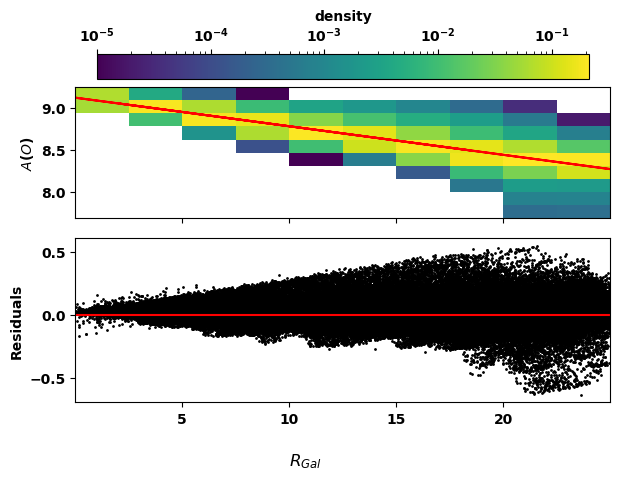

In [42]:
fig, axs = plt.subplots(2,sharex=True)
h, x_edge, y_edge, im = axs[0].hist2d(data['R_Gal'],data['A_O'],density = True,norm = 'log')
cbar = plt.colorbar(im,ax=axs[0],location = 'top',label='density')
axs[0].plot(data['R_Gal'],data['model'],c='r')
axs[0].set_ylabel('$A(O)$')
axs[1].scatter(data['R_Gal'],data['residual'],s=1,c='k')
axs[1].axhline(y=0,c='r')
axs[1].set_ylabel('Residuals')
fig.supxlabel('$R_{Gal}$')
fig.tight_layout()
fig.savefig(r'figures\A_vs_Grad.png')

In [43]:
print(f'the slope is m={params[0]:.5f}+-{np.sqrt(pcov[0,0]):.02}')
print(f'the intercept is c={params[1]:.4f}+-{np.sqrt(pcov[1,1]):.02}')

the slope is m=-0.03420+-1.5e-05
the intercept is c=9.1278+-0.00023
